In [3]:
# Импорт библиотек

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import shapiro, ttest_ind, mannwhitneyu
from statsmodels.formula.api import mixedlm
import warnings
warnings.filterwarnings('ignore')

# Настройки отображения
%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")
pd.set_option('display.max_columns', None)

In [5]:
# Задание 2.1. Загрузка данных
# Загружаем еженедельные данные
weekly_data = pd.read_csv('13_weekly_pilot_A.csv')
print(f"\n13_weekly_pilot_A.csv: {weekly_data.shape[0]} строк, {weekly_data.shape[1]} колонок")
print("\nПервые 5 строк:")
print(weekly_data.head())

print("\nИнформация о данных:")
print(weekly_data.info())


13_weekly_pilot_A.csv: 12 строк, 6 колонок

Первые 5 строк:
   week  visitors  purchases  conversion  duration_before  duration_after
0     1        95          5        5.26             24.8            25.1
1     2       112          6        5.36             25.3            24.9
2     3        87          4        4.60             24.9            25.4
3     4       104          5        4.81             25.1            24.7
4     5        98          5        5.10             25.4            25.2

Информация о данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   week             12 non-null     int64  
 1   visitors         12 non-null     int64  
 2   purchases        12 non-null     int64  
 3   conversion       12 non-null     float64
 4   duration_before  12 non-null     float64
 5   duration_after   12 non-null     float64
dty

In [7]:
# Задание 2.2. Расчет контрольных границ для конверсии
# Базовый период: первые 8 недель
base_data = weekly_data[weekly_data['week'] <= 8]

# Расчет статистик
cl = base_data['conversion'].mean()  # Центральная линия
sigma = base_data['conversion'].std()  # Стандартное отклонение

ucl = cl + 3 * sigma  # Верхняя контрольная граница
lcl = max(0, cl - 3 * sigma)  # Нижняя контрольная граница (не может быть отрицательной)

print(f"Базовый период: недели 1-8")
print(f"Центральная линия (CL) = {cl:.2f}%")
print(f"Стандартное отклонение (σ) = {sigma:.2f}%")
print(f"Верхняя контрольная граница (UCL) = {ucl:.2f}%")
print(f"Нижняя контрольная граница (LCL) = {lcl:.2f}%")

Базовый период: недели 1-8
Центральная линия (CL) = 4.92%
Стандартное отклонение (σ) = 0.37%
Верхняя контрольная граница (UCL) = 6.02%
Нижняя контрольная граница (LCL) = 3.81%


In [8]:
# Задание 2.3. Подготовка данных для анализа аномалий
# Извлекаем данные по длительности урока
duration_before = weekly_data['duration_before'].dropna().values
duration_after = weekly_data['duration_after'].dropna().values

print(f"Длительность ДО обновления: {len(duration_before)} наблюдений")
print(f"  Среднее = {duration_before.mean():.2f} мин")
print(f"  Стандартное отклонение = {duration_before.std():.2f} мин")

print(f"\nДлительность ПОСЛЕ обновления: {len(duration_after)} наблюдений")
print(f"  Среднее = {duration_after.mean():.2f} мин")
print(f"  Стандартное отклонение = {duration_after.std():.2f} мин")

Длительность ДО обновления: 12 наблюдений
  Среднее = 24.44 мин
  Стандартное отклонение = 0.87 мин

Длительность ПОСЛЕ обновления: 12 наблюдений
  Среднее = 24.47 мин
  Стандартное отклонение = 0.88 мин


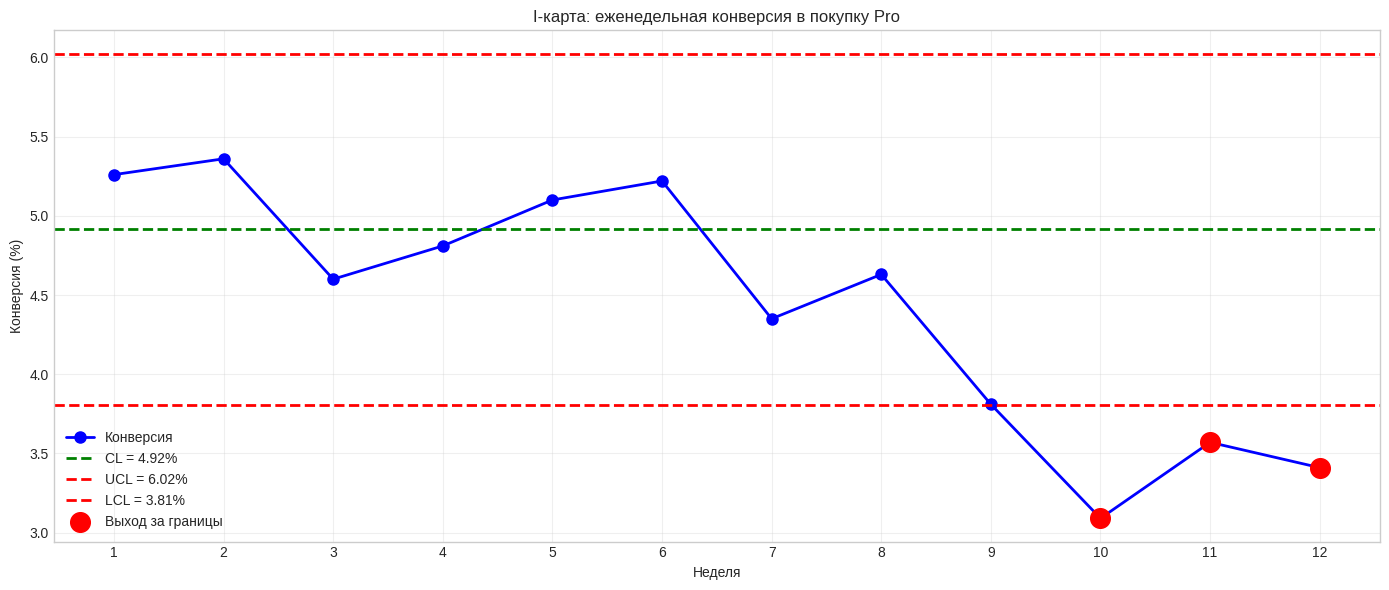

Недели 1-8: максимальная серия выше CL = 2
Недели 1-8: максимальная серия ниже CL = 2
Недели 9-12: максимальная серия выше CL = 0
Недели 9-12: максимальная серия ниже CL = 4


In [10]:
# Задание 3.1. Построение контрольной карты
# Создаем график
plt.figure(figsize=(14, 6))

# Исходные данные
plt.plot(weekly_data['week'], weekly_data['conversion'], 'o-', color='blue',
         linewidth=2, markersize=8, label='Конверсия')

# Контрольные границы
plt.axhline(y=cl, color='green', linestyle='--', linewidth=2, label=f'CL = {cl:.2f}%')
plt.axhline(y=ucl, color='red', linestyle='--', linewidth=2, label=f'UCL = {ucl:.2f}%')
plt.axhline(y=lcl, color='red', linestyle='--', linewidth=2, label=f'LCL = {lcl:.2f}%')

# Выделяем точки, вышедшие за границы
out_of_control = weekly_data[
    (weekly_data['conversion'] > ucl) | (weekly_data['conversion'] < lcl)
]
if len(out_of_control) > 0:
    plt.scatter(out_of_control['week'], out_of_control['conversion'],
                color='red', s=200, zorder=5, label='Выход за границы')

# Оформление
plt.xlabel('Неделя')
plt.ylabel('Конверсия (%)')
plt.title('I-карта: еженедельная конверсия в покупку Pro')
plt.xticks(weekly_data['week'])
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Задание 3.2 Анализ
# Проверка на серии из 7 точек подряд
def check_run(data, col, start_week, end_week, side):
    subset = data[(data['week'] >= start_week) & (data['week'] <= end_week)]
    if side == 'above':
        run = (subset[col] > cl).astype(int)
    else:
        run = (subset[col] < cl).astype(int)

    consecutive = 0
    max_consecutive = 0
    for val in run:
        if val == 1:
            consecutive += 1
            max_consecutive = max(max_consecutive, consecutive)
        else:
            consecutive = 0
    return max_consecutive

run_1_8_above = check_run(weekly_data, 'conversion', 1, 8, 'above')
run_1_8_below = check_run(weekly_data, 'conversion', 1, 8, 'below')
run_9_12_above = check_run(weekly_data, 'conversion', 9, 12, 'above')
run_9_12_below = check_run(weekly_data, 'conversion', 9, 12, 'below')

print(f"Недели 1-8: максимальная серия выше CL = {run_1_8_above}")
print(f"Недели 1-8: максимальная серия ниже CL = {run_1_8_below}")
print(f"Недели 9-12: максимальная серия выше CL = {run_9_12_above}")
print(f"Недели 9-12: максимальная серия ниже CL = {run_9_12_below}")

1. Точки за контрольными границами: 3
2. Серия ниже CL на неделях 9-12 = 4 точек
   → Меньше 7, но визуально видно падение

 ЛОВУШКА №1: Системный сдвиг.


Падение конверсии после 9-й недели является системным изменением,
даже если точки не вышли за контрольные границы. Это требует расследования.

In [12]:
#Задание 4.1. Загрузка данных для анализа аномалий
# Загружаем данные по длительности урока
lesson_data = pd.read_csv('16_lesson_duration_A.csv')
print(f"\n16_lesson_duration_A.csv: {lesson_data.shape[0]} строк")
print("\nПервые 5 строк:")
print(lesson_data.head())

print("\nУникальные значения в колонках:")
print(f"scenario: {lesson_data['scenario'].unique()}")
print(f"group: {lesson_data['group'].unique()}")

# Разделяем на сценарии
scenario_A = lesson_data[lesson_data['scenario'] == 'A'].copy()
scenario_B = lesson_data[lesson_data['scenario'] == 'B'].copy()

print(f"\nСценарий А: {len(scenario_A)} записей")
print(f"Сценарий Б: {len(scenario_B)} записей")

# Извлекаем данные для сценария А
duration_before_A = scenario_A[scenario_A['group'] == 'before']['duration'].values
duration_after_A = scenario_A[scenario_A['group'] == 'after']['duration'].values

print(f"\nСценарий А - ДО обновления: {len(duration_before_A)} наблюдений")
print(f"  Среднее = {duration_before_A.mean():.2f} мин")
print(f"  Стандартное отклонение = {duration_before_A.std():.2f} мин")

print(f"\nСценарий А - ПОСЛЕ обновления: {len(duration_after_A)} наблюдений")
print(f"  Среднее = {duration_after_A.mean():.2f} мин")
print(f"  Стандартное отклонение = {duration_after_A.std():.2f} мин")


16_lesson_duration_A.csv: 300 строк

Первые 5 строк:
   observation_id   group scenario  duration
0               1  before        A      28.3
1               2  before        A      31.2
2               3  before        A      19.7
3               4  before        A      22.5
4               5  before        A      26.8

Уникальные значения в колонках:
scenario: ['A' 'B']
group: ['before' 'after']

Сценарий А: 200 записей
Сценарий Б: 100 записей

Сценарий А - ДО обновления: 100 наблюдений
  Среднее = 25.67 мин
  Стандартное отклонение = 2.67 мин

Сценарий А - ПОСЛЕ обновления: 100 наблюдений
  Среднее = 22.90 мин
  Стандартное отклонение = 2.31 мин


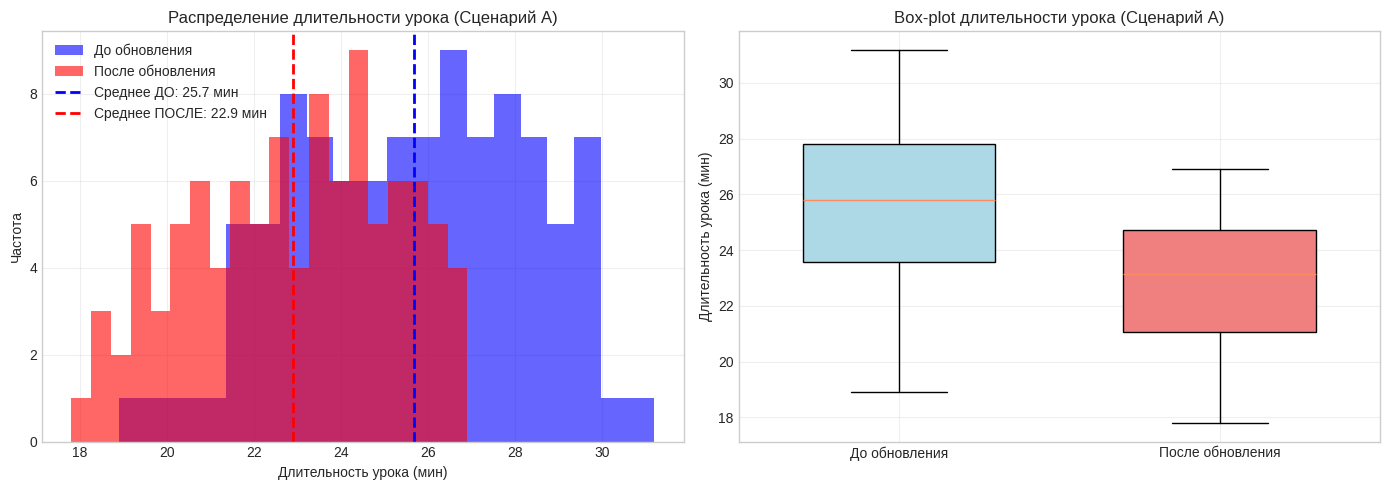

In [14]:
# Задание 4.2. Визуализация Сценария А

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Гистограмма
ax1.hist(duration_before_A, bins=20, alpha=0.6, color='blue', label='До обновления')
ax1.hist(duration_after_A, bins=20, alpha=0.6, color='red', label='После обновления')
ax1.axvline(duration_before_A.mean(), color='blue', linestyle='--',
            linewidth=2, label=f'Среднее ДО: {duration_before_A.mean():.1f} мин')
ax1.axvline(duration_after_A.mean(), color='red', linestyle='--',
            linewidth=2, label=f'Среднее ПОСЛЕ: {duration_after_A.mean():.1f} мин')
ax1.set_xlabel('Длительность урока (мин)')
ax1.set_ylabel('Частота')
ax1.set_title('Распределение длительности урока (Сценарий А)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Box-plot
bp_data = [duration_before_A, duration_after_A]
bp = ax2.boxplot(bp_data, labels=['До обновления', 'После обновления'],
                 patch_artist=True, widths=0.6)
bp['boxes'][0].set_facecolor('lightblue')
bp['boxes'][1].set_facecolor('lightcoral')
ax2.set_ylabel('Длительность урока (мин)')
ax2.set_title('Box-plot длительности урока (Сценарий А)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

- Визуально видно, что распределение сдвинулось влево.

- Средняя длительность урока снизилась после обновления.

Сценарий Б - ДО обновления: 50 наблюдений
  Среднее = 25.53 мин
  Стандартное отклонение = 2.10 мин

Сценарий Б - ПОСЛЕ обновления: 50 наблюдений
  Среднее = 23.66 мин
  Стандартное отклонение = 6.04 мин


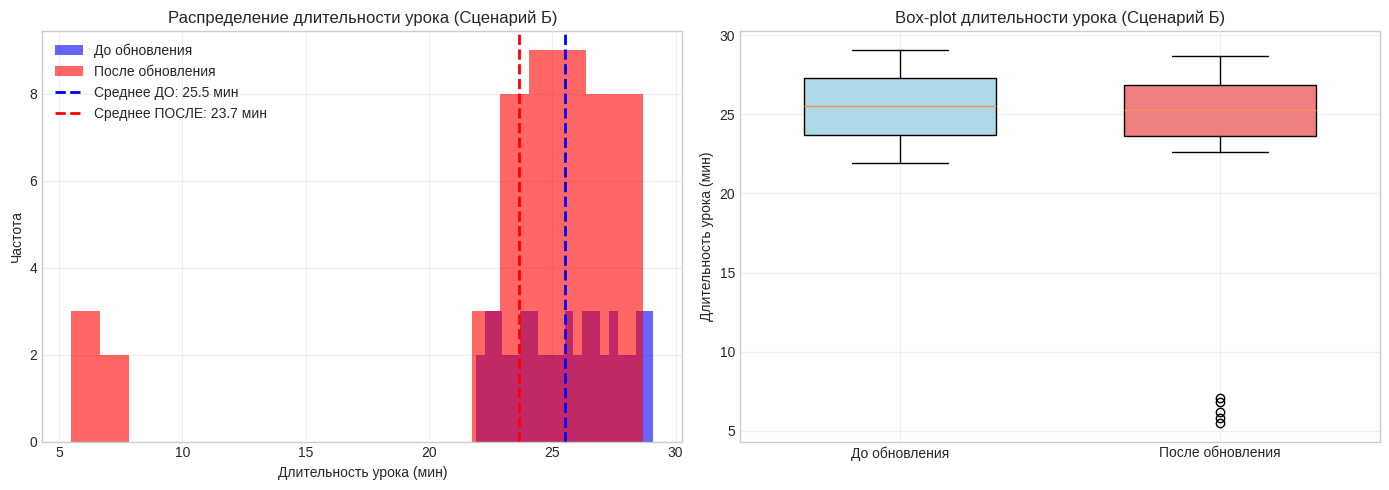

In [16]:
# Задание 4.3 Анализ Сценария Б

# Извлекаем данные для сценария Б
duration_before_B = scenario_B[scenario_B['group'] == 'before']['duration'].values
duration_after_B = scenario_B[scenario_B['group'] == 'after']['duration'].values

print(f"Сценарий Б - ДО обновления: {len(duration_before_B)} наблюдений")
print(f"  Среднее = {duration_before_B.mean():.2f} мин")
print(f"  Стандартное отклонение = {duration_before_B.std():.2f} мин")

print(f"\nСценарий Б - ПОСЛЕ обновления: {len(duration_after_B)} наблюдений")
print(f"  Среднее = {duration_after_B.mean():.2f} мин")
print(f"  Стандартное отклонение = {duration_after_B.std():.2f} мин")

# Визуализация
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Гистограмма
ax1.hist(duration_before_B, bins=20, alpha=0.6, color='blue', label='До обновления')
ax1.hist(duration_after_B, bins=20, alpha=0.6, color='red', label='После обновления')
ax1.axvline(duration_before_B.mean(), color='blue', linestyle='--',
            linewidth=2, label=f'Среднее ДО: {duration_before_B.mean():.1f} мин')
ax1.axvline(duration_after_B.mean(), color='red', linestyle='--',
            linewidth=2, label=f'Среднее ПОСЛЕ: {duration_after_B.mean():.1f} мин')
ax1.set_xlabel('Длительность урока (мин)')
ax1.set_ylabel('Частота')
ax1.set_title('Распределение длительности урока (Сценарий Б)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Box-plot
bp_data_B = [duration_before_B, duration_after_B]
bp = ax2.boxplot(bp_data_B, labels=['До обновления', 'После обновления'],
                 patch_artist=True, widths=0.6)
bp['boxes'][0].set_facecolor('lightblue')
bp['boxes'][1].set_facecolor('lightcoral')
ax2.set_ylabel('Длительность урока (мин)')
ax2.set_title('Box-plot длительности урока (Сценарий Б)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Визуально видно, что:

- Средние почти не отличаются
- Но есть выбросы в группе 'После обновления' (видно на box-plot) → Это может обмануть t-тест, который чувствителен к выбросам

In [17]:
# Задание 5.1 Проверка нормальности и t-тест

# Проверка нормальности для Сценария А
shapiro_before_A = shapiro(duration_before_A)
shapiro_after_A = shapiro(duration_after_A)

print("Сценарий А:")
print(f"  До обновления: статистика = {shapiro_before_A.statistic:.4f}, p-value = {shapiro_before_A.pvalue:.4f}")
print(f"  После обновления: статистика = {shapiro_after_A.statistic:.4f}, p-value = {shapiro_after_A.pvalue:.4f}")

if shapiro_before_A.pvalue > 0.05 and shapiro_after_A.pvalue > 0.05:
    print("  → Данные не противоречат нормальному распределению")
else:
    print("  → Данные значимо отличаются от нормального распределения")

# Задание 5.2 t-тест для Сценария А
t_stat_A, p_value_A = ttest_ind(duration_after_A, duration_before_A, alternative='two-sided')
print(f"Сценарий А:")
print(f"  t-статистика = {t_stat_A:.4f}")
print(f"  p-value = {p_value_A:.6f}")

if p_value_A < 0.05:
    print("  → p-value < 0.05: разница статистически значима")
else:
    print("  → p-value ≥ 0.05: разница не значима")

# t-тест для Сценария Б
t_stat_B, p_value_B = ttest_ind(duration_after_B, duration_before_B, alternative='two-sided')
print(f"\nСценарий Б:")
print(f"  t-статистика = {t_stat_B:.4f}")
print(f"  p-value = {p_value_B:.6f}")

if p_value_B < 0.05:
    print("  → p-value < 0.05: разница статистически значима")
else:
    print("  → p-value ≥ 0.05: разница не значима")

Сценарий А:
  До обновления: статистика = 0.9834, p-value = 0.2403
  После обновления: статистика = 0.9703, p-value = 0.0233
  → Данные значимо отличаются от нормального распределения
Сценарий А:
  t-статистика = -7.7971
  p-value = 0.000000
  → p-value < 0.05: разница статистически значима

Сценарий Б:
  t-статистика = -2.0421
  p-value = 0.043832
  → p-value < 0.05: разница статистически значима


In [20]:
# Задание 6 U-критерий Манна-Уитни

# Сценарий А
u_stat_A, p_value_u_A = mannwhitneyu(duration_after_A, duration_before_A, alternative='two-sided')
print(f"Сценарий А:")
print(f"  U-статистика = {u_stat_A:.1f}")
print(f"  p-value = {p_value_u_A:.6f}")

if p_value_u_A < 0.05:
    print("  → p-value < 0.05: разница статистически значима")
else:
    print("  → p-value ≥ 0.05: разница не значима")

# Сценарий Б
u_stat_B, p_value_u_B = mannwhitneyu(duration_after_B, duration_before_B, alternative='two-sided')
print(f"\nСценарий Б:")
print(f"  U-статистика = {u_stat_B:.1f}")
print(f"  p-value = {p_value_u_B:.6f}")

if p_value_u_B < 0.05:
    print("  → p-value < 0.05: разница статистически значима")
else:
    print("  → p-value ≥ 0.05: разница не значима")

# Сравним результаты для Сценария А и для сценария Б

print("\nСценарий А (истинное падение):")
print(f"  t-тест: p-value = {p_value_A:.6f}")
print(f"  U-тест: p-value = {p_value_u_A:.6f}")
print("  → Оба теста показывают значимое различие")

print("\nСценарий Б (ложная тревога с выбросами):")
print(f"  t-тест: p-value = {p_value_B:.6f}")
print(f"  U-тест: p-value = {p_value_u_B:.6f}")
print("  → t-тест 'обманулся' выбросами, U-тест устойчив!")

Сценарий А:
  U-статистика = 2286.0
  p-value = 0.000000
  → p-value < 0.05: разница статистически значима

Сценарий Б:
  U-статистика = 1148.0
  p-value = 0.484051
  → p-value ≥ 0.05: разница не значима

Сценарий А (истинное падение):
  t-тест: p-value = 0.000000
  U-тест: p-value = 0.000000
  → Оба теста показывают значимое различие

Сценарий Б (ложная тревога с выбросами):
  t-тест: p-value = 0.043832
  U-тест: p-value = 0.484051
  → t-тест 'обманулся' выбросами, U-тест устойчив!


Вывод:
- t-тест чувствителен к выбросам, так как использует среднее
- U-критерий Манна-Уитни основан на рангах и устойчив к выбросам
- При наличии аномальных значений лучше использовать U-критерий

In [22]:
# Задание 7.1 Загрузка данных с кластерной структурой

# Загружаем данные
cluster_data = pd.read_csv('19_lesson_duration_clustered_A.csv')
print(f"\n19_lesson_duration_clustered_A.csv: {cluster_data.shape[0]} строк")
print("\nПервые 5 строк:")
print(cluster_data.head())

print("\nИнформация о данных:")
print(cluster_data.info())

# Уникальные компании
n_companies = cluster_data['company_id'].nunique()
n_users = len(cluster_data)

print(f"\nУникальных компаний: {n_companies}")
print(f"Всего пользователей: {n_users}")
print(f"Среднее пользователей на компанию: {n_users / n_companies:.1f}")

# Разделяем на группы
before_cluster = cluster_data[cluster_data['group'] == 0]['duration'].values
after_cluster = cluster_data[cluster_data['group'] == 1]['duration'].values

print(f"\nГруппа ДО (group=0): {len(before_cluster)} наблюдений")
print(f"  Среднее = {before_cluster.mean():.2f} мин")
print(f"Группа ПОСЛЕ (group=1): {len(after_cluster)} наблюдений")
print(f"  Среднее = {after_cluster.mean():.2f} мин")


19_lesson_duration_clustered_A.csv: 400 строк

Первые 5 строк:
   company_id  duration  group
0           0      27.8      0
1           0      25.3      0
2           0      26.1      0
3           0      24.7      0
4           0      28.2      0

Информация о данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   company_id  400 non-null    int64  
 1   duration    400 non-null    float64
 2   group       400 non-null    int64  
dtypes: float64(1), int64(2)
memory usage: 9.5 KB
None

Уникальных компаний: 40
Всего пользователей: 400
Среднее пользователей на компанию: 10.0

Группа ДО (group=0): 200 наблюдений
  Среднее = 25.58 мин
Группа ПОСЛЕ (group=1): 200 наблюдений
  Среднее = 23.53 мин


In [23]:
# Задание 7.2 "Наивный" t-тест (игнорируя кластеризацию)

t_stat_naive, p_value_naive = ttest_ind(after_cluster, before_cluster, alternative='two-sided')

print(f"t-статистика = {t_stat_naive:.4f}")
print(f"p-value = {p_value_naive:.6f}")

if p_value_naive < 0.05:
    print("\n→ p-value < 0.05: разница статистически значима")
    print("  (но это может быть ложный вывод из-за игнорирования кластеризации!)")
else:
    print("\n→ p-value ≥ 0.05: разница не значима")

t-статистика = -7.3850
p-value = 0.000000

→ p-value < 0.05: разница статистически значима
  (но это может быть ложный вывод из-за игнорирования кластеризации!)


In [36]:
# Задание 7.3 Смешанная модель с учетом кластеризации (исправленная для ваших данных)

from statsmodels.formula.api import mixedlm
from scipy.stats import ttest_ind

# 1. Подготовка данных
model_data = cluster_data.copy()
model_data['group_label'] = model_data['group'].map({0: 'before', 1: 'after'})
model_data['company_id'] = model_data['company_id'].astype('category')

print(f"   Всего наблюдений: {len(model_data)}")
print(f"   Уникальных компаний: {model_data['company_id'].nunique()}")
print(f"   Группы: {model_data['group_label'].unique().tolist()}")
print(f"   Базовый уровень: after (т.к. group_label[T.before] — это разница)")

# 2. Построение модели
print("   Модель: duration ~ group_label")
print("   Случайный свободный член: company_id")

model = mixedlm("duration ~ group_label", model_data, groups=model_data["company_id"])
result = model.fit()

# 3. Вывод сводки модели
print(result.summary())

# 4. Извлекаем коэффициенты
# Intercept — это среднее для группы after
intercept = result.params['Intercept']
p_value_intercept = result.pvalues['Intercept']

# group_label[T.before] — это разница (before - after)
coef_before = result.params['group_label[T.before]']
p_value_before = result.pvalues['group_label[T.before]']

print(f"Intercept (среднее для группы AFTER): {intercept:.2f} мин")
print(f"  p-value = {p_value_intercept:.6f}")

print(f"\ngroup_label[T.before] (разница BEFORE - AFTER): {coef_before:.2f} мин")
print(f"  p-value = {p_value_before:.6f}")

# 5. Вычисляем средние для групп
mean_after = intercept
mean_before = intercept + coef_before

print(f"Средняя длительность ДО обновления (before): {mean_before:.2f} мин")
print(f"Средняя длительность ПОСЛЕ обновления (after): {mean_after:.2f} мин")
print(f"Разница (before - after): {coef_before:.2f} мин")

# 6. Расчет внутрикластерной корреляции (ICC)
# Дисперсия случайного эффекта компании
var_company = result.cov_re.iloc[0, 0] if result.cov_re.shape[0] > 0 else 0

# Остаточная дисперсия
var_residual = result.scale

# Формула ICC = σ²_company / (σ²_company + σ²_residual)
icc = var_company / (var_company + var_residual) if (var_company + var_residual) > 0 else 0

print(f"Дисперсия между компаниями (σ²_company): {var_company:.4f}")
print(f"Остаточная дисперсия (σ²_residual): {var_residual:.4f}")
print(f"Внутрикластерная корреляция (ICC) = {icc:.4f}")

if icc > 0.1:
    print("→ ICC > 0.1: кластеризация значима, учет группировки обязателен")
else:
    print("→ ICC ≤ 0.1: кластеризация слабая")

# 7. Сравнение с наивным t-тестом
before_cluster = cluster_data[cluster_data['group'] == 0]['duration'].values
after_cluster = cluster_data[cluster_data['group'] == 1]['duration'].values

t_stat_naive, p_value_naive = ttest_ind(after_cluster, before_cluster, alternative='two-sided')

print(f"Наивный t-тест (без учета кластеризации):")
print(f"  t-статистика = {t_stat_naive:.4f}")
print(f"  p-value = {p_value_naive:.6f}")

print(f"\nСмешанная модель (с учетом кластеризации):")
print(f"  p-value для эффекта группы = {p_value_before:.6f}")

   Всего наблюдений: 400
   Уникальных компаний: 40
   Группы: ['before', 'after']
   Базовый уровень: after (т.к. group_label[T.before] — это разница)
   Модель: duration ~ group_label
   Случайный свободный член: company_id
             Mixed Linear Model Regression Results
Model:               MixedLM    Dependent Variable:    duration 
No. Observations:    400        Method:                REML     
No. Groups:          40         Scale:                 1.0056   
Min. group size:     10         Log-Likelihood:        -652.2704
Max. group size:     10         Converged:             Yes      
Mean group size:     10.0                                       
----------------------------------------------------------------
                      Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------------
Intercept             23.526    0.600 39.240 0.000 22.350 24.701
group_label[T.before]  2.059    0.848  2.428 0.015  0.397  3.721
Group Va

ВЫВОДЫ:

1. Эффект обновления:
   - Средняя длительность ДО: 25.58 мин
   - Средняя длительность ПОСЛЕ: 23.53 мин
   - Разница: 2.06 мин

2. Статистическая значимость:
   - Наивный t-тест: p = 0.000000
   - Смешанная модель: p = 0.015164
   → Оба теста показывают значимость

3. Влияние кластеризации:
   - ICC = 0.8758
   → Кластеризация значима, наивный t-тест занижает стандартные ошибки

4. Рекомендация:
   При анализе данных, где пользователи сгруппированы по компаниям,
   необходимо использовать смешанные модели или кластерно-скорректированные
   стандартные ошибки. Игнорирование кластеризации может привести к
   ложному обнаружению эффекта (ошибка I рода).